<a href="https://colab.research.google.com/github/jhlopesalves/eda_humanidades/blob/main/encontro_5/datasaurus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interlúdio: Datasaurus Dozen

**Instrutor:** Jhonatan Lopes

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="darkgrid", context="notebook")

### Funções auxiliares

As funções abaixo organizam os cálculos e as visualizações utilizados nesta
demonstração. Sua implementação não constitui o objeto principal da análise.

In [2]:
#| code-fold: true
#| code-summary: "Mostrar função auxiliar"

def cohens_d(
    first_group: pd.Series | np.ndarray,
    second_group: pd.Series | np.ndarray,
) -> float:
    """Cohen's d entre dois grupos, com desvio-padrão combinado (ddof=1)."""
    first_values = np.asarray(first_group)
    second_values = np.asarray(second_group)

    n_first = len(first_values)
    n_second = len(second_values)

    pooled_variance = (
        (n_first - 1) * first_values.var(ddof=1)
        + (n_second - 1) * second_values.var(ddof=1)
    ) / (n_first + n_second - 2)

    pooled_standard_deviation = np.sqrt(pooled_variance)

    return float(
        (first_values.mean() - second_values.mean())
        / pooled_standard_deviation
    )

In [3]:
#| code-fold: true
#| code-summary: "Mostrar função auxiliar"

def compare_stats(
    data: pd.DataFrame,
    group1: str,
    group2: str,
) -> pd.DataFrame:

    df1 = data[data["dataset"] == group1]
    df2 = data[data["dataset"] == group2]

    columns = pd.MultiIndex.from_tuples(
        [
            ("x", group1.capitalize()),
            ("x", group2.capitalize()),
            ("y", group1.capitalize()),
            ("y", group2.capitalize()),
        ]
    )

    comparison = pd.DataFrame(
        [
            [
                df1["x"].mean(),
                df2["x"].mean(),
                df1["y"].mean(),
                df2["y"].mean(),
            ],
            [
                df1["x"].median(),
                df2["x"].median(),
                df1["y"].median(),
                df2["y"].median(),
            ],
            [
                df1["x"].var(ddof=1),
                df2["x"].var(ddof=1),
                df1["y"].var(ddof=1),
                df2["y"].var(ddof=1),
            ],
            [
                df1["x"].std(ddof=1),
                df2["x"].std(ddof=1),
                df1["y"].std(ddof=1),
                df2["y"].std(ddof=1),
            ],
        ],
        index=["Média", "Mediana", "Variância", "Desvio-padrão"],
        columns=columns,
    )

    return comparison

In [4]:
#| code-fold: true
#| code-summary: "Mostrar função auxiliar"

def plot_pair(
    data: pd.DataFrame,
    datasets: list[str],
) -> None:
    """Diagramas de dispersão lado a lado para os subconjuntos indicados."""
    subset = data[data["dataset"].isin(datasets)]

    grid = sns.FacetGrid(
        subset,
        col="dataset",
        col_wrap=2,
        height=4,
    )

    grid.map_dataframe(
        sns.scatterplot,
        x="x",
        y="y",
        s=20,
        linewidth=0,
    )

    grid.set(xlim=(0, 100), ylim=(0, 100))
    grid.set_axis_labels("x", "y")
    grid.set_titles("{col_name}")

    plt.show()

## 1. Estrutura dos dados

Datasaurus Dozen contém observações identificadas por três variáveis:
`dataset`, `x` e `y`.

`dataset` identifica o subconjunto ao qual cada observação pertence; `x` e `y`
registram duas coordenadas quantitativas.

Antes de selecionar subconjuntos específicos, examinaremos apenas a estrutura
básica da tabela.

In [5]:
from pathlib import Path

datasaurus_path = Path("data/datasaurus.csv")
datasaurus_url = (
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/"
    "main/data/2020/2020-10-13/datasaurus.csv"
)

if datasaurus_path.exists():
    datasaurus_df = pd.read_csv(datasaurus_path)
else:
    datasaurus_df = pd.read_csv(datasaurus_url)

In [6]:
datasaurus_df.shape

(1846, 3)

In [7]:
datasaurus_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1846 entries, 0 to 1845
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dataset  1846 non-null   str    
 1   x        1846 non-null   float64
 2   y        1846 non-null   float64
dtypes: float64(2), str(1)
memory usage: 43.4 KB


In [8]:
datasaurus_df.head()

,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333


In [9]:
datasaurus_df["dataset"].value_counts()

dataset
dino          142
away          142
h_lines       142
v_lines       142
x_shape       142
star          142
high_lines    142
dots          142
circle        142
bullseye      142
slant_up      142
slant_down    142
wide_lines    142
Name: count, dtype: int64

A tabela contém 1.846 observações distribuídas igualmente entre 13
subconjuntos, com 142 observações em cada um.

A unidade de observação é um ponto definido pelo par de coordenadas `(x, y)`,
associado a uma categoria de `dataset`. Não há valores ausentes nas três
variáveis.

Para a primeira comparação, utilizaremos os subconjuntos `dino` e `star`.

In [10]:
star = datasaurus_df.loc[
    datasaurus_df["dataset"] == "star",
    ["x", "y"],
]

dino = datasaurus_df.loc[
    datasaurus_df["dataset"] == "dino",
    ["x", "y"],
]

## 2. Resumos marginais

Nesta etapa, `x` e `y` são examinados separadamente em cada subconjunto.
Os resultados são, portanto, **resumos marginais**: cada estatística descreve
uma coordenada de cada vez.

### 2.1 Média aritmética

Para $n$ observações $x_1, x_2, \ldots, x_n$, a média aritmética é:

$$
\bar{x}
=
\frac{1}{n}
\sum_{i=1}^{n} x_i
$$

em que $\bar{x}$ representa a média dos valores observados e $n$ o número de
observações.

O cálculo será realizado separadamente para as coordenadas `x` e `y` dos
subconjuntos `dino` e `star`.

In [11]:
print(
    f"Dino - média: x = {dino['x'].mean():.3f}; "
    f"y = {dino['y'].mean():.3f}"
)

print(
    f"Star - média: x = {star['x'].mean():.3f}; "
    f"y = {star['y'].mean():.3f}"
)

Dino - média: x = 54.263; y = 47.832
Star - média: x = 54.267; y = 47.840


As médias das duas coordenadas são praticamente iguais nos dois subconjuntos.

### 2.2 Mediana

Considere os valores ordenados:

$$
x_{(1)} \leq x_{(2)} \leq \cdots \leq x_{(n)}
$$

A mediana é dada por:

$$
\operatorname{mediana}(x)
=
\begin{cases}
x_{\left(\frac{n+1}{2}\right)},
& \text{se } n \text{ é ímpar} \\[6pt]
\frac{
x_{\left(\frac{n}{2}\right)}
+
x_{\left(\frac{n}{2}+1\right)}
}{2},
& \text{se } n \text{ é par}
\end{cases}
$$

A mediana depende da posição dos valores depois da ordenação e, por isso, é
menos sensível à magnitude de observações extremas do que a média.

In [12]:
print(
    f"Dino - mediana: x = {dino['x'].median():.3f}; "
    f"y = {dino['y'].median():.3f}"
)

print(
    f"Star - mediana: x = {star['x'].median():.3f}; "
    f"y = {star['y'].median():.3f}"
)

Dino - mediana: x = 53.333; y = 46.026
Star - mediana: x = 56.535; y = 50.111


As medianas não coincidem. As diferenças entre `dino` e `star` são maiores
aqui do que nas médias, embora os valores ainda ocupem regiões semelhantes das
respectivas escalas.

### 2.3 Variância

A variância quantifica a dispersão dos valores em torno da média. Utilizaremos
a forma com denominador $n-1$:

$$
s^2
=
\frac{1}{n-1}
\sum_{i=1}^{n}
(x_i-\bar{x})^2
$$

Valores maiores de $s^2$ correspondem, nessa escala, a maior dispersão em torno
da média.

Em pandas, `Series.var(ddof=1)` implementa essa convenção utilizando
explicitamente um grau de liberdade no denominador.

In [ ]:
print(
    f"Dino - variância: x = {dino['x'].var(ddof=1):.3f}; "
    f"y = {dino['y'].var(ddof=1):.3f}"
)

print(
    f"Star - variância: x = {star['x'].var(ddof=1):.3f}; "
    f"y = {star['y'].var(ddof=1):.3f}"
)

Dino - variância: x = 281.070; y = 725.516
Star - variância: x = 281.198; y = 725.240


As variâncias de `x` e de `y` são muito próximas nos dois subconjuntos.

### 2.4 Desvio-padrão

O desvio-padrão é a raiz quadrada da variância:

$$
s = \sqrt{s^2}
$$

Ao contrário da variância, o desvio-padrão é expresso na mesma unidade da
variável original. Para as coordenadas deste conjunto, ele descreve a dispersão
de `x` e `y` na própria escala dessas coordenadas.

Como $s$ é determinado diretamente por $s^2$, variâncias semelhantes produzem
necessariamente desvios-padrão semelhantes.

In [ ]:
print(
    f"Dino - desvio-padrão: x = {dino['x'].std(ddof=1):.3f}; "
    f"y = {dino['y'].std(ddof=1):.3f}"
)

print(
    f"Star - desvio-padrão: x = {star['x'].std(ddof=1):.3f}; "
    f"y = {star['y'].std(ddof=1):.3f}"
)

Dino - desvio-padrão: x = 16.765; y = 26.935
Star - desvio-padrão: x = 16.769; y = 26.930


## 3. Diferença padronizada entre médias: Cohen's $d$

Os resumos anteriores mostram médias e medidas de dispersão muito semelhantes
para `dino` e `star`. Podemos também expressar a diferença entre as médias em
relação à variabilidade observada nos dois conjuntos.

Cohen's $d$ é uma medida padronizada de diferença entre médias. Seu valor
expressa essa diferença em unidades de desvio-padrão.

Calcularemos $d$ separadamente para `x` e `y`.

Para dois grupos, Cohen's $d$ pode ser calculado por:

$$
d
=
\frac{\bar{x}_1-\bar{x}_2}{s_p}
$$

em que:

$$
s_p
=
\sqrt{
\frac{
(n_1-1)s_1^2+(n_2-1)s_2^2
}{
n_1+n_2-2
}
}
$$

$\bar{x}_1$ e $\bar{x}_2$ representam as médias dos grupos; $s_1^2$ e $s_2^2$,
suas variâncias; e $n_1$ e $n_2$, seus números de observações.

O sinal de $d$ indica a direção da diferença. Como estamos interessados apenas
em sua magnitude nesta comparação, utilizaremos $|d|$.

Valores próximos de zero correspondem a médias próximas em relação ao
desvio-padrão agrupado; valores absolutos maiores correspondem a maior separação
padronizada entre as médias.

In [ ]:
d_x = abs(
    cohens_d(
        first_group=dino["x"],
        second_group=star["x"],
    )
)

d_y = abs(
    cohens_d(
        first_group=dino["y"],
        second_group=star["y"],
    )
)

print(f"|d| para x: {d_x:.4f}")
print(f"|d| para y: {d_y:.4f}")

|d| para x: 0.0002
|d| para y: 0.0003


Os valores de $|d|$ são praticamente zero para as duas coordenadas. Em termos
de diferença padronizada entre médias, `dino` e `star` apresentam separação
muito pequena tanto em `x` quanto em `y`.

In [ ]:
dino_star_comparison = compare_stats(
    datasaurus_df,
    "dino",
    "star",
)


In [ ]:
#| echo: false

dino_star_comparison.style.format(
    precision=3,
).set_caption("Dino vs. Star: estatísticas descritivas")


In [ ]:
print(
    "Os resumos marginais e Cohen’s d parecem encerrar a questão. "
    "Agora vamos observar os pares (x, y)."
)

Os resumos marginais e Cohen’s d parecem encerrar a questão. Agora vamos observar os pares (x, y).


## 4. Representação gráfica

Os mesmos dados podem ser examinados graficamente. O gráfico de dispersão
representa cada observação pelo par de coordenadas `(x, y)`.

Os dois painéis utilizam os mesmos limites nos eixos.

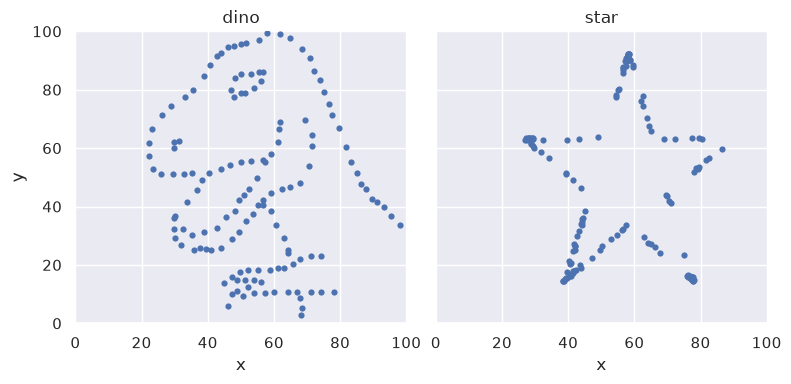

In [ ]:
#| label: fig-dino-star
#| fig-cap: "Dino e Star: estruturas distintas apesar de resumos marginais semelhantes."
#| fig-alt: "Dois diagramas de dispersão lado a lado: os pontos do primeiro formam a silhueta de um dinossauro e os do segundo formam uma estrela."

plot_pair(data=datasaurus_df, datasets=["dino", "star"])

### 4.1 Inspeção dos dados, pressupostos e escolha do método

Os gráficos mostram que `dino` e `star` possuem estruturas claramente
diferentes. A distinção é imédiata quando os pares `(x, y)` são examinados
diretamente.

Se tivéssemos produzido o gráfico de dispersão logo após a inspeção inicial dos
dados, não haveria dúvida relevante sobre esse ponto. Os resumos numéricos
anteriores não tornaram os conjuntos semelhantes; apenas resumiram aspectos dos
dados que, neste caso, eram semelhantes.

A sequência utilizada nesta demonstração foi deliberadamente inadequada.
Calculamos sucessivos resumos e, em seguida, utilizamos Cohen's $d$ como se
uma diferença padronizada entre médias pudesse estabelecer se os dois conjuntos
de pontos eram semelhantes.

Esse não é o problema que Cohen's $d$ foi concebido para resolver.

Cohen's $d$ descreve uma diferença entre médias relativamente a uma medida de
variabilidade. Utilizá-lo como uma medida geral de diferença entre
distribuições ou entre conjuntos de dados extrapola o que a estatística
representa.

O código foi executado corretamente e os valores calculados correspondem às
fórmulas utilizadas. A análise, porém, foi completamente inadequada.

Essa distinção será fundamental a partir deste ponto do curso. Métodos
estatísticos possuem **pressupostos**, condições de aplicação e interpretações
específicas. Esses elementos são parte constitutiva da escolha do método e,
portanto, não podem ser tratados como uma verificação opcional realizada
depois do cálculo.

Nenhum software estatístico ou linguagem de programação assume essa
responsabilidade pelo pesquisador. Python pode calcular uma correlação, um
tamanho de efeito, um teste de hipótese ou um modelo sempre que a operação
estiver computacionalmente definida. Em muitos casos, nenhuma mensagem de erro
será produzida quando o procedimento for estatisticamente **inadequado**.

Por isso, a escolha de um método deve preceder sua execução e considerar, entre
outros aspectos:

1. a unidade de observação e a forma como os dados foram produzidos;
2. a pergunta estatística que se pretende responder;
3. a estrutura e a distribuição dos dados;
4. os pressupostos do procedimento considerado;
5. o que a estatística resultante representa - e o que ela não representa.

A inspeção dos dados faz parte desse processo. Para dados quantitativos
bidimensionais como estes, o gráfico de dispersão deveria normalmente aparecer
no início da análise, e não apenas depois dos resumos numéricos.

Uma estatística não se torna adequada porque produz um número plausível, porque
está disponível em uma biblioteca ou porque seu uso se tornou convencional
entre alguns pesquisadores.

## 5. Comparação adicional: `bullseye` e `away`

O mesmo procedimento gráfico pode ser aplicado a outros subconjuntos de
Datasaurus Dozen.

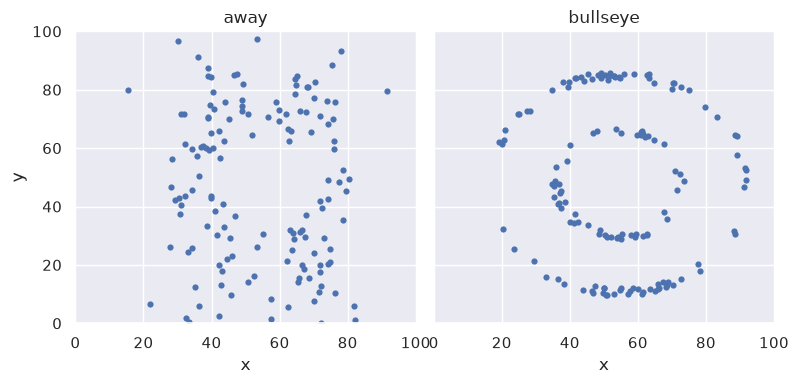

In [ ]:
#| label: fig-bullseye-away
#| fig-cap: "Bullseye e Away: outra comparação entre estruturas espaciais distintas."
#| fig-alt: "Dois diagramas de dispersão lado a lado: Bullseye forma anéis concêntricos, enquanto Away espalha os pontos em uma nuvem irregular."

plot_pair(data=datasaurus_df, datasets=["bullseye", "away"])

### 5.1 Adequação estatística

`bullseye` e `away` reforçam o mesmo ponto: conjuntos de observações podem
diferir de maneira evidente em sua estrutura mesmo quando determinados
resumos numéricos permanecem praticamente idênticos.

A conclusão não é que precisamos encontrar uma estatística mais poderosa capaz
de detectar qualquer diferença entre dois conjuntos de dados. Existem medidas
globais de discrepância entre distribuições, mas detectar que dois conjuntos
diferem não é o mesmo que descrever em que eles diferem: nenhum escalar
preserva essa informação.

O procedimento adequado depende da pergunta formulada. Diferenças de
localização, dispersão, associação, densidade, assimetria, multimodalidade ou
estrutura geométrica correspondem a propriedades distintas e podem exigir
representações e métodos diferentes.

::: {.callout-note}
### Nota metodológica: Cohen's $d$ e tradições estatísticas na linguística de corpus

Cohen's $d$ é utilizado em parte da literatura de linguística de corpus para
quantificar diferenças entre frequências médias de traços linguísticos em dois
corpora ou registros. Em algumas abordagens, os valores de $d$ são também
utilizados para ordenar os traços segundo a magnitude dessas diferenças.

Essa utilização trata Cohen's $d$ como uma medida relativamente geral de
diferença entre grupos. A convenção, porém, não altera o que a estatística
representa: uma diferença entre médias padronizada por uma medida de
variabilidade. Sua adequação continua dependendo da unidade de observação, do
desenho da comparação, das distribuições envolvidas e dos pressupostos da
formulação utilizada.

A linguística de corpus não apresenta, contudo, uma única tradição estatística.
Uma linha mais antiga - que podemos caracterizar como *old school* - atribui
grande importância a frequências normalizadas, médias, desvios-padrão e medidas
escalares utilizadas para comparar corpora ou registros. Esses procedimentos
podem ser informativos em situações adequadas, mas tornam-se problemáticos
quando a heterogeneidade entre textos, a forma das distribuições, a dispersão
das ocorrências e os pressupostos das medidas recebem pouca atenção.

Uma tradição mais recente e estatisticamente rigorosa tem tratado esses
problemas como parte central da análise. Stefan Th. Gries, em
[*Dispersions and adjusted frequencies in corpora* (2008)](https://benjamins.com/catalog/ijcl.13.4.02gri),
chama a atenção diretamente para o fato de que frequências isoladas podem ser
enganosas quando a dispersão das ocorrências é ignorada. Em
[*Frequency, Dispersion, Association, and Keyness: Revising and tupleizing corpus-linguistic measures* (2024)](https://benjamins.com/catalog/scl.115),
Gries leva o argumento adiante: frequência, dispersão, associação e *keyness*
fornecem dimensões distintas de informação, e reduzi-las automaticamente a um
único número pode comprometer a interpretação.

Vaclav Brezina desenvolve uma perspectiva semelhante em
[*Statistics in Corpus Linguistics: A Practical Guide* (2018)](https://www.cambridge.org/core/books/statistics-in-corpus-linguistics/4E530F86B328B2287681AD240796D2CF),
colocando princípios de raciocínio estatístico, visualização e escolha de
procedimentos no centro da análise de dados de corpus. O projeto
[Lancaster Stats Tools](https://corpus-stats.lancs.ac.uk/) fornece também
materiais, exemplos e ferramentas associados a essa abordagem.

No âmbito mais amplo da estatística aplicada à linguística, Bodo Winter, em
[*Statistics for Linguists: An Introduction Using R* (2019)](https://www.routledge.com/Statistics-for-Linguists-An-Introduction-Using-R/Winter/p/book/9781138056091),
trata explicitamente distribuições, pressupostos, independência, diagnóstico de
modelos e escolha metodológica, culminando numa defesa de modelagem orientada
pela teoria em lugar de procedimentos de tipo *cookbook*.

A **dispersão** constitui um exemplo particularmente claro da diferença entre
essas perspectivas. Duas formas linguísticas podem apresentar a mesma
frequência total em um corpus e, ainda assim, possuir distribuições muito
diferentes. Uma pode ocorrer de maneira relativamente regular em muitos textos;
a outra pode estar quase inteiramente concentrada em poucos documentos.

Gries (2008) propõe a medida *Deviation of Proportions* $DP$ para
quantificar essa propriedade. Para cada parte $i$ do corpus, compara-se a
proporção observada das ocorrências do item, $v_i$, com a proporção que essa
parte representa no tamanho total do corpus, $s_i$:

$$
DP
=
\frac{1}{2}
\sum_{i=1}^{n}
|v_i-s_i|
$$

Valores menores correspondem a distribuições mais próximas daquela esperada a
partir dos tamanhos das partes; valores maiores indicam maior concentração das
ocorrências em determinadas partes do corpus.

Nesse tipo de comparação, o problema começa quando a diferença entre corpora é
reduzida a uma diferença entre frequências médias padronizada pelo
desvio-padrão.

Quando um corpus é constituído por muitos textos, a distribuição das
ocorrências entre esses textos faz parte da estrutura analisada. Como o
exemplo acima mostra, duas frequências médias semelhantes podem resultar de
padrões radicalmente diferentes.

Cohen's $d$, utilizado como um escore geral para ordenar diferenças entre
corpora, preserva apenas a diferença padronizada entre médias. A distribuição
das ocorrências entre textos permanece fora dessa representação.

Medidas de dispersão como $DP$ tornam essa dimensão explícita. Elas mostram
como as ocorrências se distribuem pelas partes do corpus e permitem distinguir
padrões que frequências médias semelhantes ocultariam.

A tradição estatisticamente mais rigorosa da linguística de corpus trata esse
problema como multifatorial. Frequência, tendência central, dispersão,
associação, heterogeneidade entre textos e forma das distribuições descrevem
propriedades distintas dos dados. Cada uma exige medidas compatíveis com a
pergunta formulada.

Essa perspectiva também favorece procedimentos de modelagem quando a estrutura
dos dados exige considerar simultaneamente tamanho dos textos, variabilidade
entre documentos, fatores de contexto ou outras fontes sistemáticas de
heterogeneidade.

Uma análise que comprime essas dimensões em um único escore perde informação
sobre a estrutura observada. Valores numericamente corretos podem, assim,
sustentar uma representação estatisticamente inadequada do fenômeno.
:::

## 6. Princípios para a análise estatística

Este encontro antecipou alguns conceitos que serão desenvolvidos com mais
detalhe ao longo da parte estatística do curso. Termos como **distribuição**,
**pressupostos**, **adequação do método**, **tamanho de efeito** e
**modelagem** aparecem aqui para estabelecer desde o início a lógica que
orientará as análises posteriores.

A presença de Cohen's $d$ nesta demonstração foi deliberada. Seu uso reproduz
uma prática encontrada em parte da literatura de linguística de corpus: resumir
diferenças entre grupos por meio de uma diferença padronizada entre médias.
Datasaurus permitiu mostrar, antes mesmo de estudarmos formalmente tamanhos de
efeito e testes estatísticos, o quanto uma conclusão depende da medida
escolhida e de qual aspecto da estrutura dos dados essa medida preserva.

A partir deste ponto, uma análise estatística começa pela compreensão dos dados
e da pergunta formulada. A unidade de observação, o desenho da comparação, a
escala das variáveis, a forma das distribuições e as relações entre as
observações determinam quais procedimentos possuem uma interpretação
estatisticamente defensável.

A visualização participa diretamente desse processo. Histogramas, gráficos de
densidade, boxplots, gráficos de dispersão e outras representações permitem
examinar características das distribuições que medidas escalares comprimem:
assimetria, multimodalidade, concentração, valores extremos, heterogeneidade e
formas de associação.

Os pressupostos pertencem à escolha do método. Correlações, testes de hipótese,
tamanhos de efeito e modelos estatísticos respondem a perguntas diferentes
e operam sob condições diferentes. A função disponível em SciPy, statsmodels
ou outra biblioteca constitui apenas a implementação computacional do
procedimento.

O fluxo de trabalho adotado daqui em diante será, em linhas gerais:

1. identificar a unidade de observação e a estrutura dos dados;
2. inspecionar numericamente e visualizar as distribuições relevantes;
3. formular com precisão a quantidade, relação ou diferença de interesse;
4. escolher um procedimento compatível com a pergunta e com seus pressupostos;
5. examinar diagnósticos, sensibilidade e limitações antes de interpretar o
   resultado.

Datasaurus forneceu uma primeira demonstração desse princípio. Os cálculos
produziram valores perfeitamente plausíveis; a inspeção dos pontos mostrou que
a pergunta que estávamos tentando responder exigia outra representação da
estrutura dos dados.